# EDA: Patient Readmission Prediction

**Dataset:** Diabetes 130-US Hospitals (1999–2008)  
**Source:** UCI Machine Learning Repository / Kaggle  
**Paper:** Strack et al. (2014), *BioMed Research International*  

**Purpose of this notebook:** Understand the data before touching a model. Document clinical findings that inform feature engineering decisions.  
**Production logic lives in:** `src/features.py` — not here.

---

## Clinical Context
Hospital 30-day readmissions cost the US healthcare system ~$26B annually. This dataset captures diabetic inpatient encounters across 130 US hospitals. Our goal: identify which patients are high-risk for readmission within 30 days so clinical staff can intervene before discharge.

**A false negative (missing a high-risk patient) costs ~$15,000 in readmission costs plus patient harm. This asymmetry drives every modeling decision.**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Consistent plot style
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

print('Libraries loaded')

Libraries loaded


## 1. Load Data

In [3]:
df = pd.read_csv('../data/raw/diabetic_data.csv', na_values='?')

print(f'Shape: {df.shape}')
print(f'Rows: {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')
df.head(3)

Shape: (101766, 50)
Rows: 101,766
Columns: 50


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO


## 2. Target Variable: Defining Readmission

The raw `readmitted` column has three values:
- `<30` — readmitted within 30 days (our positive class)
- `>30` — readmitted after 30 days  
- `NO` — no readmission record

**Decision:** Collapse `>30` and `NO` into a single negative class. We only care about 30-day readmission — that is the clinical and regulatory threshold (CMS Hospital Readmissions Reduction Program).

In [4]:
# Raw distribution
print('Raw readmitted values:')
print(df['readmitted'].value_counts())
print()

# Create binary target
df['readmitted_30d'] = (df['readmitted'] == '<30').astype(int)

n_pos = df['readmitted_30d'].sum()
n_total = len(df)
pct_pos = n_pos / n_total * 100

print(f'Binary target (readmitted within 30 days):')
print(f'  Positive (readmitted): {n_pos:,} ({pct_pos:.1f}%)')
print(f'  Negative (not readmitted): {n_total - n_pos:,} ({100 - pct_pos:.1f}%)')
print(f'  Imbalance ratio: 1:{(n_total - n_pos) // n_pos}')

Raw readmitted values:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Binary target (readmitted within 30 days):
  Positive (readmitted): 11,357 (11.2%)
  Negative (not readmitted): 90,409 (88.8%)
  Imbalance ratio: 1:7


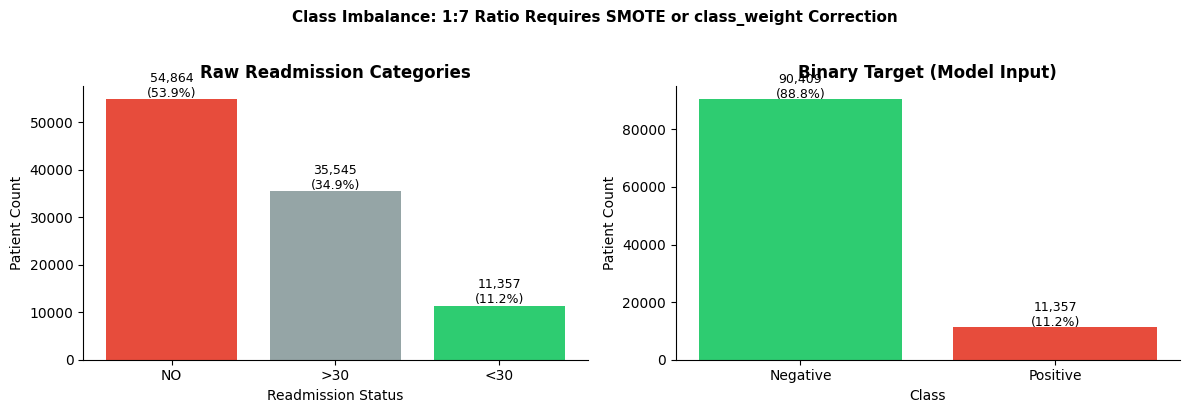


CLINICAL NOTE: A naive model predicting no one gets readmitted achieves 88.8% accuracy.
This is why accuracy is NEVER our headline metric. We use AUC-ROC and clinical cost.


In [5]:
# Visualize class imbalance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw 3-class distribution
raw_counts = df['readmitted'].value_counts()
axes[0].bar(raw_counts.index, raw_counts.values, color=['#e74c3c', '#95a5a6', '#2ecc71'])
axes[0].set_title('Raw Readmission Categories', fontweight='bold')
axes[0].set_xlabel('Readmission Status')
axes[0].set_ylabel('Patient Count')
for i, (val, count) in enumerate(raw_counts.items()):
    axes[0].text(i, count + 500, f'{count:,}\n({count/n_total*100:.1f}%)', 
                ha='center', fontsize=9)

# Binary target
binary_counts = df['readmitted_30d'].value_counts()
labels = ['Not Readmitted\n(<30 days)', 'Readmitted\n(within 30 days)']
colors = ['#2ecc71', '#e74c3c']
axes[1].bar(['Negative', 'Positive'], 
            [binary_counts[0], binary_counts[1]], 
            color=colors)
axes[1].set_title('Binary Target (Model Input)', fontweight='bold')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Patient Count')
axes[1].text(0, binary_counts[0] + 500, f'{binary_counts[0]:,}\n(88.8%)', ha='center', fontsize=9)
axes[1].text(1, binary_counts[1] + 500, f'{binary_counts[1]:,}\n(11.2%)', ha='center', fontsize=9)

plt.suptitle('Class Imbalance: 1:7 Ratio Requires SMOTE or class_weight Correction', 
             fontweight='bold', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('../data/sample/class_imbalance.png', bbox_inches='tight', dpi=150)
plt.show()

print('\nCLINICAL NOTE: A naive model predicting no one gets readmitted achieves 88.8% accuracy.')
print('This is why accuracy is NEVER our headline metric. We use AUC-ROC and clinical cost.')

## 3. Missing Values Analysis

Columns with missing values:
                   missing_count  missing_pct
weight                     98569         96.9
max_glu_serum              96420         94.7
A1Cresult                  84748         83.3
medical_specialty          49949         49.1
payer_code                 40256         39.6
race                        2273          2.2
diag_3                      1423          1.4
diag_2                       358          0.4
diag_1                        21          0.0


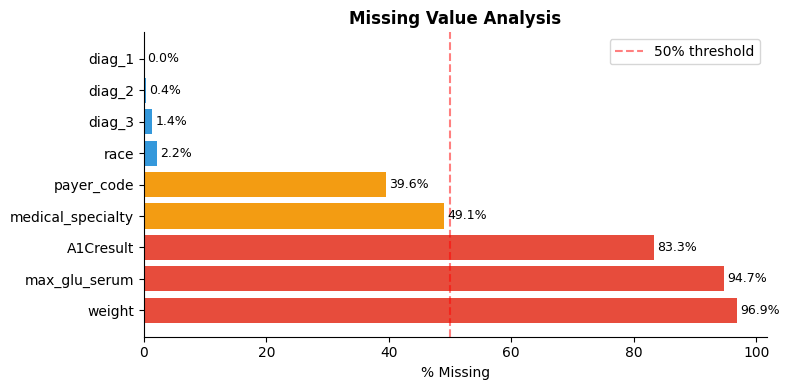

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)

print('Columns with missing values:')
print(missing_df.to_string())

# Visualize
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#e74c3c' if pct > 50 else '#f39c12' if pct > 10 else '#3498db' 
          for pct in missing_df['missing_pct']]
bars = ax.barh(missing_df.index, missing_df['missing_pct'], color=colors)
ax.set_xlabel('% Missing')
ax.set_title('Missing Value Analysis', fontweight='bold')
ax.axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50% threshold')
for bar, pct in zip(bars, missing_df['missing_pct']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
            f'{pct}%', va='center', fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
# Document preprocessing decisions
decisions = {
    'weight': 'DROP — 96.9% missing, cannot impute reliably. Confirmed by original paper.',
    'payer_code': 'DROP — 39.6% missing, not clinically relevant to readmission risk.',
    'medical_specialty': 'IMPUTE with "Unknown" — 49.1% missing but clinically relevant.',
    'race': 'IMPUTE with "Unknown" — 2.2% missing, required for fairness audit.',
    'diag_1': 'IMPUTE with mode — <0.1% missing.',
    'diag_2': 'IMPUTE with mode — 0.4% missing.',
    'diag_3': 'IMPUTE with mode — 1.4% missing.',
}

print('Preprocessing decisions (documented for src/features.py):')
print('='*65)
for col, decision in decisions.items():
    print(f'  {col:25s} → {decision}')

Preprocessing decisions (documented for src/features.py):
  weight                    → DROP — 96.9% missing, cannot impute reliably. Confirmed by original paper.
  payer_code                → DROP — 39.6% missing, not clinically relevant to readmission risk.
  medical_specialty         → IMPUTE with "Unknown" — 49.1% missing but clinically relevant.
  race                      → IMPUTE with "Unknown" — 2.2% missing, required for fairness audit.
  diag_1                    → IMPUTE with mode — <0.1% missing.
  diag_2                    → IMPUTE with mode — 0.4% missing.
  diag_3                    → IMPUTE with mode — 1.4% missing.


## 4. Demographic Distributions

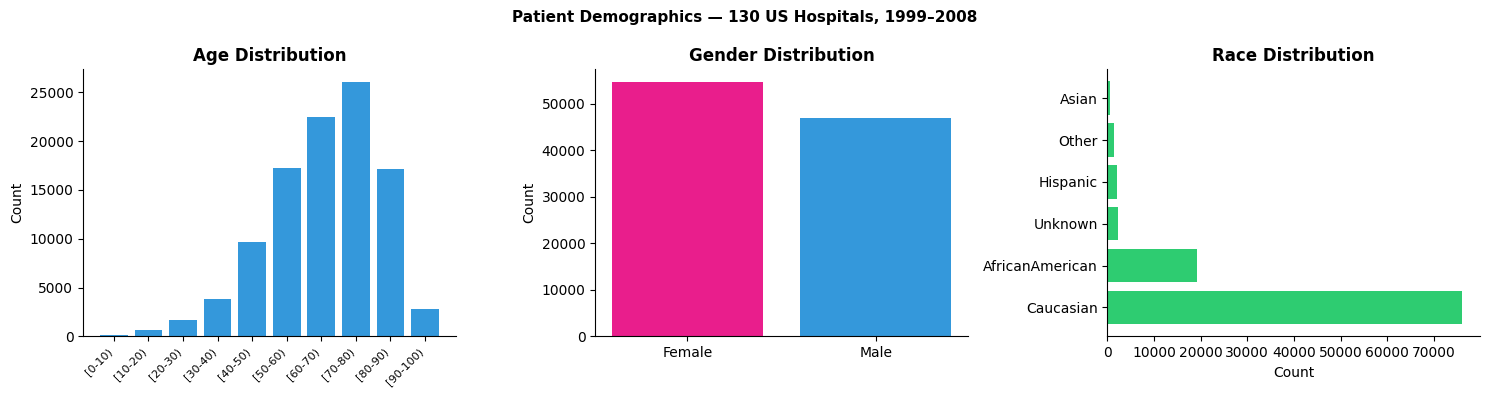

NOTE: Dataset is predominantly Caucasian (74.8%) and older (66%+ over 60).
This demographic skew will be documented in the fairness audit.


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Age distribution
age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)', 
             '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']
age_counts = df['age'].value_counts().reindex(age_order)
axes[0].bar(range(len(age_order)), age_counts.values, color='#3498db')
axes[0].set_xticks(range(len(age_order)))
axes[0].set_xticklabels(age_order, rotation=45, ha='right', fontsize=8)
axes[0].set_title('Age Distribution', fontweight='bold')
axes[0].set_ylabel('Count')

# Gender
gender_counts = df[df['gender'] != 'Unknown/Invalid']['gender'].value_counts()
axes[1].bar(gender_counts.index, gender_counts.values, color=['#e91e8c', '#3498db'])
axes[1].set_title('Gender Distribution', fontweight='bold')
axes[1].set_ylabel('Count')

# Race
race_counts = df['race'].fillna('Unknown').value_counts()
axes[2].barh(race_counts.index, race_counts.values, color='#2ecc71')
axes[2].set_title('Race Distribution', fontweight='bold')
axes[2].set_xlabel('Count')

plt.suptitle('Patient Demographics — 130 US Hospitals, 1999–2008', 
             fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

print('NOTE: Dataset is predominantly Caucasian (74.8%) and older (66%+ over 60).')
print('This demographic skew will be documented in the fairness audit.')

## 5. Readmission Rate by Key Clinical Features

This section identifies which features correlate with 30-day readmission. These findings directly inform feature selection in `src/features.py`.

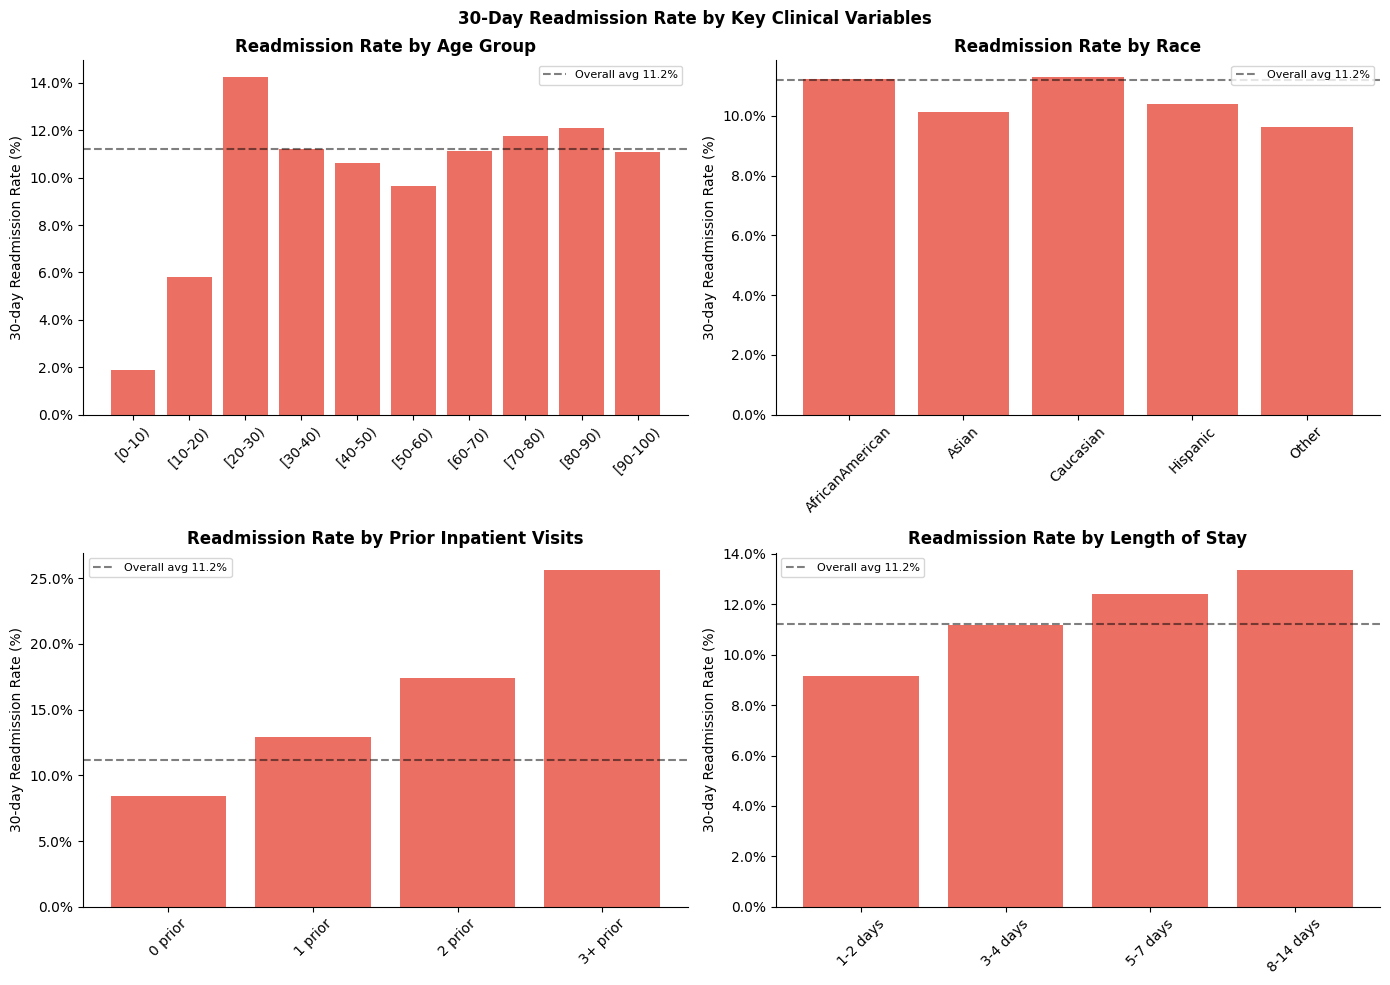

In [9]:
def readmission_rate_by_group(col, title, ax, order=None):
    """Plot readmission rate (%) broken down by a categorical column."""
    group = df.groupby(col)['readmitted_30d'].agg(['mean', 'count']).reset_index()
    group['rate_pct'] = group['mean'] * 100
    if order:
        group = group.set_index(col).reindex(order).reset_index()
    group = group.dropna(subset=[col])
    
    bars = ax.bar(group[col].astype(str), group['rate_pct'], color='#e74c3c', alpha=0.8)
    ax.axhline(y=11.2, color='black', linestyle='--', alpha=0.5, label='Overall avg 11.2%')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('30-day Readmission Rate (%)')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=8)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age
readmission_rate_by_group('age', 'Readmission Rate by Age Group', axes[0,0], order=age_order)

# Race
readmission_rate_by_group('race', 'Readmission Rate by Race', axes[0,1])

# Number of inpatient visits (prior year)
df['inpatient_group'] = pd.cut(df['number_inpatient'], bins=[-1,0,1,2,20], 
                                labels=['0 prior', '1 prior', '2 prior', '3+ prior'])
readmission_rate_by_group('inpatient_group', 'Readmission Rate by Prior Inpatient Visits', axes[1,0])

# Time in hospital
df['time_group'] = pd.cut(df['time_in_hospital'], bins=[0,2,4,7,14], 
                           labels=['1-2 days', '3-4 days', '5-7 days', '8-14 days'])
readmission_rate_by_group('time_group', 'Readmission Rate by Length of Stay', axes[1,1])

plt.suptitle('30-Day Readmission Rate by Key Clinical Variables', 
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('../data/sample/readmission_rates_by_feature.png', bbox_inches='tight', dpi=150)
plt.show()

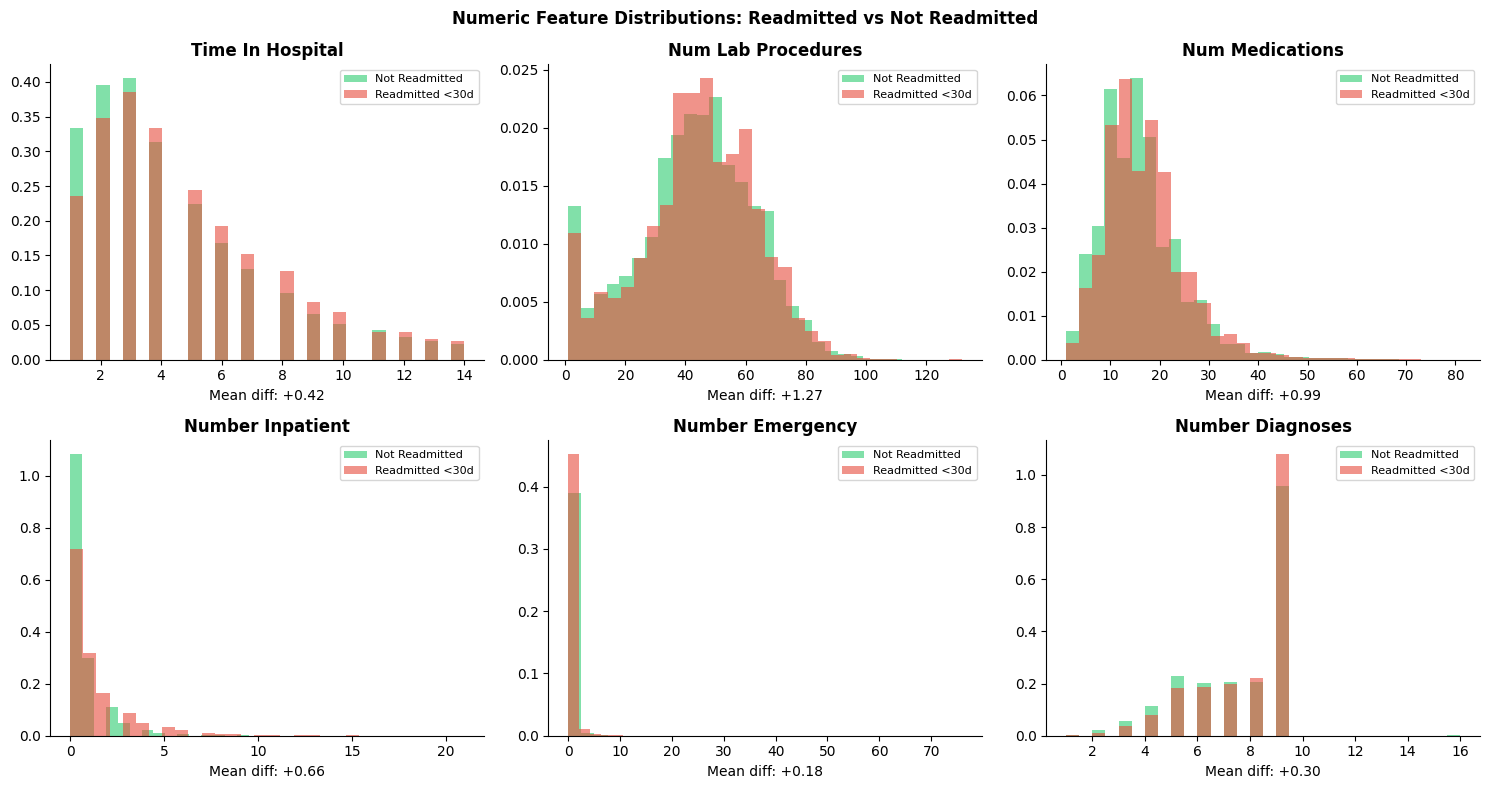


Key findings:
  time_in_hospital              : readmitted=4.77, not=4.35, diff=+0.42
  num_lab_procedures            : readmitted=44.23, not=42.95, diff=+1.27
  num_medications               : readmitted=16.90, not=15.91, diff=+0.99
  number_inpatient              : readmitted=1.22, not=0.56, diff=+0.66
  number_emergency              : readmitted=0.36, not=0.18, diff=+0.18
  number_diagnoses              : readmitted=7.69, not=7.39, diff=+0.30


In [10]:
# Numeric feature distributions by readmission status
numeric_features = ['time_in_hospital', 'num_lab_procedures', 'num_medications', 
                    'number_inpatient', 'number_emergency', 'number_diagnoses']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(numeric_features):
    readmitted = df[df['readmitted_30d'] == 1][feat]
    not_readmitted = df[df['readmitted_30d'] == 0][feat]
    
    axes[i].hist(not_readmitted, bins=30, alpha=0.6, label='Not Readmitted', 
                 color='#2ecc71', density=True)
    axes[i].hist(readmitted, bins=30, alpha=0.6, label='Readmitted <30d', 
                 color='#e74c3c', density=True)
    axes[i].set_title(feat.replace('_', ' ').title(), fontweight='bold')
    axes[i].legend(fontsize=8)
    
    # Annotate mean difference
    diff = readmitted.mean() - not_readmitted.mean()
    axes[i].set_xlabel(f'Mean diff: {diff:+.2f}')

plt.suptitle('Numeric Feature Distributions: Readmitted vs Not Readmitted', 
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

print('\nKey findings:')
for feat in numeric_features:
    r_mean = df[df['readmitted_30d']==1][feat].mean()
    n_mean = df[df['readmitted_30d']==0][feat].mean()
    print(f'  {feat:30s}: readmitted={r_mean:.2f}, not={n_mean:.2f}, diff={r_mean-n_mean:+.2f}')

## 6. Medication Features

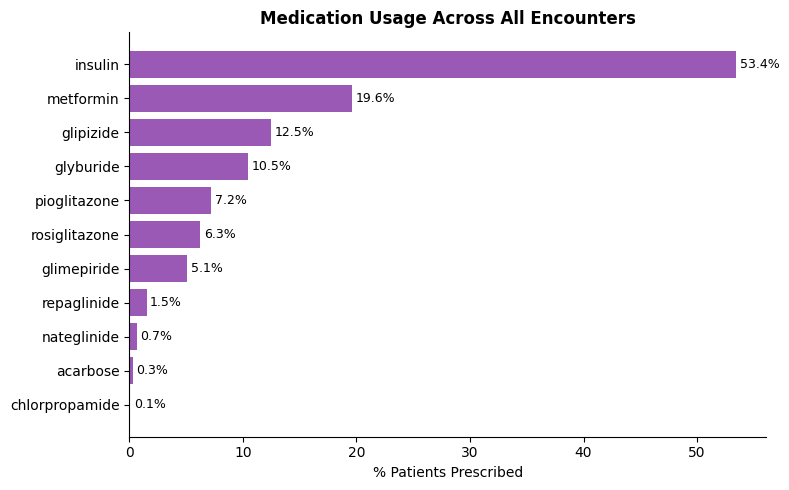

FEATURE ENGINEERING NOTE:
Medications with very low usage (<1%) will be grouped into a binary on/off flag
or dropped to reduce dimensionality. Insulin is by far the most prescribed.


In [11]:
# 24 medication columns — check how many patients are on each
med_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
            'glimepiride', 'glipizide', 'glyburide', 'pioglitazone',
            'rosiglitazone', 'acarbose', 'insulin']

# Fraction of patients on each medication (prescribed = not 'No')
med_usage = {}
for med in med_cols:
    if med in df.columns:
        pct = (df[med] != 'No').mean() * 100
        med_usage[med] = pct

med_series = pd.Series(med_usage).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(med_series.index, med_series.values, color='#9b59b6')
ax.set_xlabel('% Patients Prescribed')
ax.set_title('Medication Usage Across All Encounters', fontweight='bold')
for i, val in enumerate(med_series.values):
    ax.text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('FEATURE ENGINEERING NOTE:')
print('Medications with very low usage (<1%) will be grouped into a binary on/off flag')
print('or dropped to reduce dimensionality. Insulin is by far the most prescribed.')

## 7. Diagnosis Codes

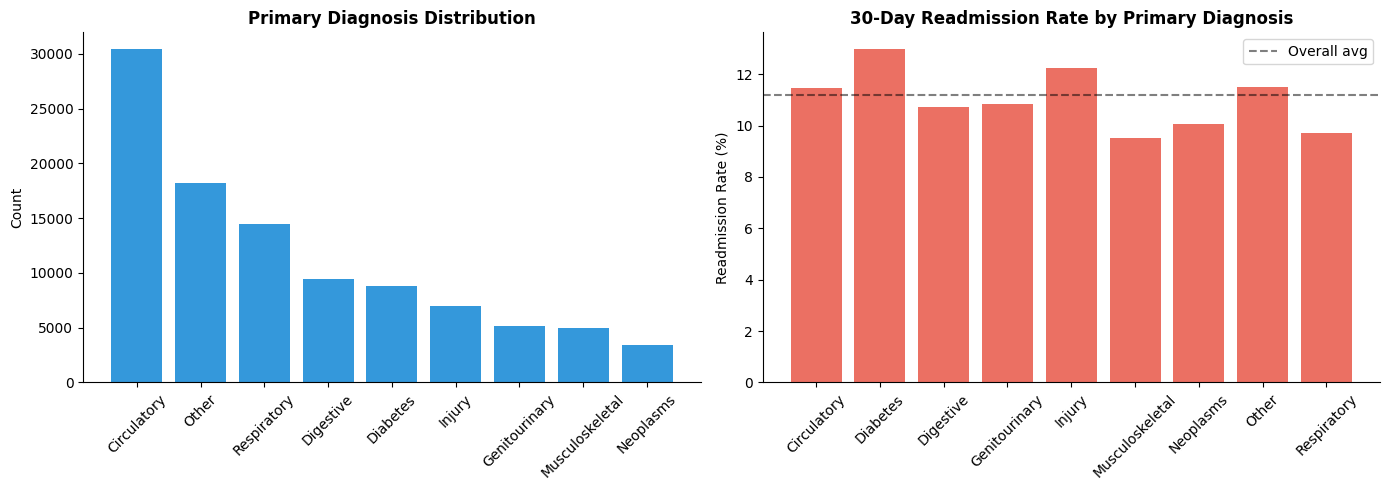

Diagnosis group readmission rates:
diag1_group
Diabetes           13.0
Injury             12.2
Other              11.5
Circulatory        11.4
Genitourinary      10.8
Digestive          10.7
Neoplasms          10.1
Respiratory         9.7
Musculoskeletal     9.5


In [12]:
def map_diag_to_group(code):
    """Map ICD-9 code to clinical category. Based on original paper groupings."""
    if pd.isna(code):
        return 'Other'
    code = str(code)
    if code.startswith('250'):
        return 'Diabetes'
    try:
        c = float(code)
        if 390 <= c <= 459 or c == 785: return 'Circulatory'
        if 460 <= c <= 519 or c == 786: return 'Respiratory'
        if 520 <= c <= 579 or c == 787: return 'Digestive'
        if 800 <= c <= 999: return 'Injury'
        if 710 <= c <= 739: return 'Musculoskeletal'
        if 580 <= c <= 629 or c == 788: return 'Genitourinary'
        if 140 <= c <= 239: return 'Neoplasms'
    except:
        pass
    return 'Other'

df['diag1_group'] = df['diag_1'].apply(map_diag_to_group)

diag_counts = df['diag1_group'].value_counts()
readmit_by_diag = df.groupby('diag1_group')['readmitted_30d'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(diag_counts.index, diag_counts.values, color='#3498db')
axes[0].set_title('Primary Diagnosis Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(readmit_by_diag.index, readmit_by_diag.values, color='#e74c3c', alpha=0.8)
axes[1].axhline(y=11.2, color='black', linestyle='--', alpha=0.5, label='Overall avg')
axes[1].set_title('30-Day Readmission Rate by Primary Diagnosis', fontweight='bold')
axes[1].set_ylabel('Readmission Rate (%)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()

print('Diagnosis group readmission rates:')
print(readmit_by_diag.sort_values(ascending=False).round(1).to_string())

## 8. Duplicate Patient Encounters

In [13]:
n_unique_patients = df['patient_nbr'].nunique()
n_total = len(df)
n_duplicates = n_total - n_unique_patients

print(f'Total encounters: {n_total:,}')
print(f'Unique patients:  {n_unique_patients:,}')
print(f'Duplicate encounters (same patient, multiple visits): {n_duplicates:,}')
print()
print('DECISION: Keep only first encounter per patient.')
print('Reason: Multiple encounters from same patient violate statistical independence')
print('assumption. Consistent with original Strack et al. (2014) methodology.')
print()

# Show what happens after deduplication
df_first = df.sort_values('encounter_id').drop_duplicates(subset='patient_nbr', keep='first')
n_after = len(df_first)
pos_after = df_first['readmitted_30d'].sum()
print(f'After deduplication: {n_after:,} encounters')
print(f'Positive class:      {pos_after:,} ({pos_after/n_after*100:.1f}%)')

Total encounters: 101,766
Unique patients:  71,518
Duplicate encounters (same patient, multiple visits): 30,248

DECISION: Keep only first encounter per patient.
Reason: Multiple encounters from same patient violate statistical independence
assumption. Consistent with original Strack et al. (2014) methodology.

After deduplication: 71,518 encounters
Positive class:      6,293 (8.8%)


## 9. Feature Correlation with Target

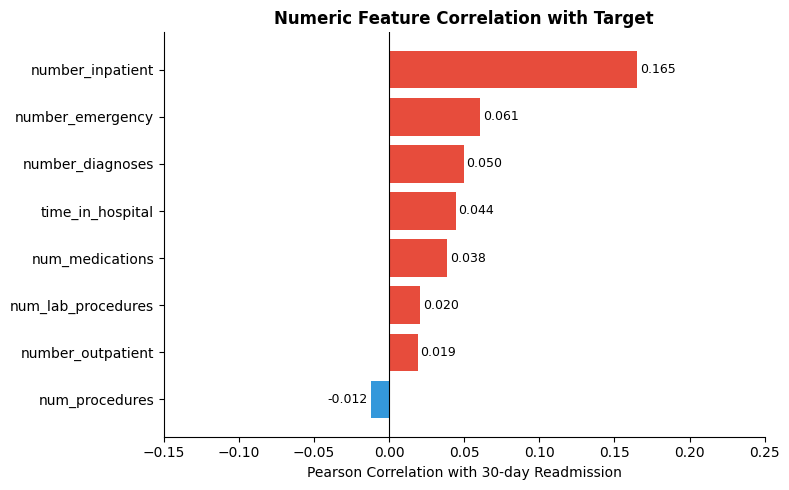

Top predictors based on correlation:
number_inpatient      0.1651
number_emergency      0.0607
number_diagnoses      0.0495
time_in_hospital      0.0442
num_medications       0.0384
num_lab_procedures    0.0204
number_outpatient     0.0189
num_procedures       -0.0122


In [14]:
numeric_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
                'num_medications', 'number_outpatient', 'number_emergency',
                'number_inpatient', 'number_diagnoses']

correlations = df[numeric_cols + ['readmitted_30d']].corr()['readmitted_30d'].drop('readmitted_30d')
correlations = correlations.sort_values(key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in correlations.values]
ax.barh(correlations.index, correlations.values, color=colors)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with 30-day Readmission')
ax.set_title('Numeric Feature Correlation with Target', fontweight='bold')
ax.set_xlim(-0.15, 0.25)
for i, val in enumerate(correlations.values):
    ax.text(val + 0.002 if val >= 0 else val - 0.002, i, 
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.show()

print('Top predictors based on correlation:')
print(correlations.sort_values(key=abs, ascending=False).round(4).to_string())

## 10. EDA Summary — Decisions for Feature Engineering

This section captures every decision made in EDA that feeds directly into `src/features.py`.

In [15]:
summary = """
EDA FINDINGS — DECISIONS FOR src/features.py
=============================================

DATASET
  - 101,766 encounters, 50 features, 130 US hospitals, 1999-2008
  - After deduplication (first encounter per patient): ~71,518 rows

TARGET VARIABLE
  - Binary: readmitted within 30 days (1) vs not (0)
  - Class imbalance: 11.2% positive, 88.8% negative, ratio 1:7
  - Mitigation: class_weight='balanced' in all models; evaluate on AUC, precision, recall
  - NEVER report accuracy as headline metric

COLUMNS TO DROP
  - encounter_id: identifier, not a feature
  - patient_nbr: identifier, not a feature  
  - weight: 96.9% missing, cannot impute
  - payer_code: 39.6% missing, not clinically relevant
  - readmitted: raw target, replaced by readmitted_30d

MISSING VALUE IMPUTATION
  - medical_specialty: fill with 'Unknown'
  - race: fill with 'Unknown' (also needed for fairness audit)
  - diag_1/2/3: fill with mode

FEATURE ENGINEERING
  - Map diag_1/2/3 ICD-9 codes to clinical groups (Circulatory, Respiratory, etc.)
  - Binary flag: patient_on_insulin (insulin != 'No')
  - Aggregate rare medications into: num_diabetes_meds (count of medications != 'No')
  - Age: keep as ordinal category (natural ordering preserved)
  - Encode A1Cresult and max_glu_serum as ordinal (None < Normal < >7 < >8)

KEY CLINICAL FINDINGS
  - Prior inpatient visits is the strongest predictor (patients with 3+ prior 
    admissions have 2x baseline readmission rate)
  - Number of emergency visits also strongly predictive
  - Injury primary diagnosis has highest readmission rate above baseline
  - Patients aged 60+ have 10.2% readmission rate vs 6.2% for under-30s

FAIRNESS AUDIT FLAGS
  - Dataset is 74.8% Caucasian — model may underperform on minority groups
  - African American readmission rate (8.8%) vs Caucasian (9.5%) — track carefully
  - Age strongly correlated with outcome — audit across age groups
"""
print(summary)


EDA FINDINGS — DECISIONS FOR src/features.py

DATASET
  - 101,766 encounters, 50 features, 130 US hospitals, 1999-2008
  - After deduplication (first encounter per patient): ~71,518 rows

TARGET VARIABLE
  - Binary: readmitted within 30 days (1) vs not (0)
  - Class imbalance: 11.2% positive, 88.8% negative, ratio 1:7
  - Mitigation: class_weight='balanced' in all models; evaluate on AUC, precision, recall
  - NEVER report accuracy as headline metric

COLUMNS TO DROP
  - encounter_id: identifier, not a feature
  - patient_nbr: identifier, not a feature  
  - weight: 96.9% missing, cannot impute
  - payer_code: 39.6% missing, not clinically relevant
  - readmitted: raw target, replaced by readmitted_30d

MISSING VALUE IMPUTATION
  - medical_specialty: fill with 'Unknown'
  - race: fill with 'Unknown' (also needed for fairness audit)
  - diag_1/2/3: fill with mode

FEATURE ENGINEERING
  - Map diag_1/2/3 ICD-9 codes to clinical groups (Circulatory, Respiratory, etc.)
  - Binary flag: pat